# Analyse de sensibilité sur κ — Modèle de Chiarella étendu

**Objectif** : Comprendre l'impact du paramètre de rappel fondamental κ sur :
- L'amplitude des bulles (mispricing P−V)
- La volatilité des rendements
- Les propriétés statistiques (skewness, kurtosis)

Tous les autres paramètres sont fixés (`MONTHLY_PARAMS`), γ est constant (baseline).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from src.model import ChiarellaModel, ModelParams
from src.simulation import MONTHLY_PARAMS
from src.analysis import compute_returns, return_statistics

sns.set_theme(style='whitegrid', palette='tab10')
SEED = 2024

## 1. Paramètres du sweep

In [2]:
KAPPA_VALUES = [0.01, 0.02, 0.05, 0.08, 0.15, 0.30, 0.50]

# Paramètres de base (on va juste changer kappa à chaque itération)
BASE_PARAMS = MONTHLY_PARAMS
print(f"Paramètres de base : {BASE_PARAMS}")
print(f"Valeurs de κ testées : {KAPPA_VALUES}")

Paramètres de base : ModelParams(kappa=0.08, beta=0.1, alpha=0.14285714285714285, gamma0=2.0, sigma_N=0.05, sigma_V=0.02, g=0.0, dt=1.0, T=1000.0)
Valeurs de κ testées : [0.01, 0.02, 0.05, 0.08, 0.15, 0.3, 0.5]


## 2. Simulation pour chaque valeur de κ

In [3]:
from dataclasses import replace

records = []

for kappa in KAPPA_VALUES:
    params = replace(BASE_PARAMS, kappa=kappa)
    model = ChiarellaModel(params=params, seed=SEED)
    res = model.simulate(n_paths=1)

    mispricing = res.P - res.V
    returns = compute_returns(res.P)
    stats = return_statistics(returns, annualization_factor=np.sqrt(12))  # mensuel → annuel

    records.append({
        'kappa':        kappa,
        'std_mispricing': float(np.std(mispricing)),
        'max_mispricing': float(np.max(np.abs(mispricing))),
        'vol_annualisee': stats['vol'],
        'skewness':       stats['skewness'],
        'kurtosis_exc':   stats['kurt_excess'],
        'jb_pval':        stats['jarque_bera_pval'],
        # On garde les trajectoires pour les graphiques
        '_t':   res.t,
        '_P':   res.P,
        '_V':   res.V,
    })

df_stats = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in records])
df_stats

,kappa,std_mispricing,max_mispricing,vol_annualisee,skewness,kurtosis_exc,jb_pval
0,0.01,0.316874,0.907329,0.177108,0.044236,0.132808,0.588294
1,0.02,0.255547,0.709060,0.177702,0.049846,0.125147,0.586645
2,0.05,0.173912,0.546472,0.179098,0.048741,0.085358,0.704854
3,0.08,0.138652,0.465620,0.180522,0.043516,0.073758,0.762508
4,0.15,0.102605,0.361581,0.184137,0.037153,0.075960,0.790384
5,0.30,0.076112,0.266265,0.192762,0.025126,0.089852,0.801873
6,0.50,0.063109,0.239307,0.206082,0.017000,0.116057,0.737349


## 3. Impact de κ sur le mispricing et la volatilité

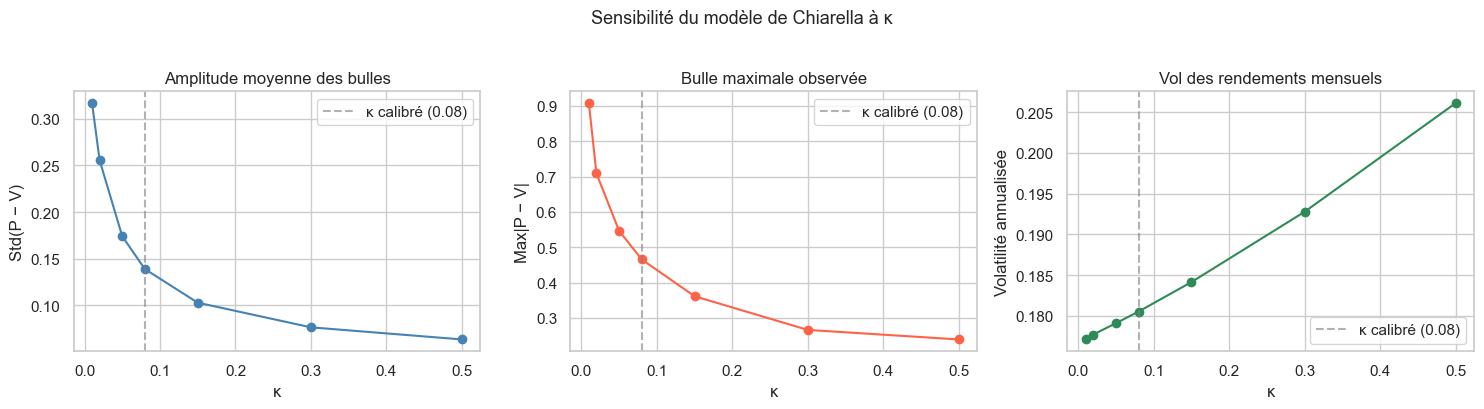

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Std(P-V) ---
axes[0].plot(df_stats['kappa'], df_stats['std_mispricing'], 'o-', color='steelblue')
axes[0].axvline(0.08, color='gray', linestyle='--', alpha=0.6, label='κ calibré (0.08)')
axes[0].set_xlabel('κ')
axes[0].set_ylabel('Std(P − V)')
axes[0].set_title('Amplitude moyenne des bulles')
axes[0].legend()

# --- Max|P-V| ---
axes[1].plot(df_stats['kappa'], df_stats['max_mispricing'], 'o-', color='tomato')
axes[1].axvline(0.08, color='gray', linestyle='--', alpha=0.6, label='κ calibré (0.08)')
axes[1].set_xlabel('κ')
axes[1].set_ylabel('Max|P − V|')
axes[1].set_title('Bulle maximale observée')
axes[1].legend()

# --- Vol annualisée ---
axes[2].plot(df_stats['kappa'], df_stats['vol_annualisee'], 'o-', color='seagreen')
axes[2].axvline(0.08, color='gray', linestyle='--', alpha=0.6, label='κ calibré (0.08)')
axes[2].set_xlabel('κ')
axes[2].set_ylabel('Volatilité annualisée')
axes[2].set_title('Vol des rendements mensuels')
axes[2].legend()

fig.suptitle('Sensibilité du modèle de Chiarella à κ', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Tableau récapitulatif

In [5]:
df_display = df_stats[['kappa', 'std_mispricing', 'max_mispricing', 'vol_annualisee', 'skewness', 'kurtosis_exc']].copy()
df_display.columns = ['κ', 'Std(P−V)', 'Max|P−V|', 'Vol annualisée', 'Skewness', 'Kurtosis excéd.']

# Variation relative par rapport à κ = 0.08 (baseline)
baseline_row = df_display[df_display['κ'] == 0.08].iloc[0]
for col in ['Std(P−V)', 'Max|P−V|', 'Vol annualisée']:
    df_display[f'Δ {col}'] = ((df_display[col] - baseline_row[col]) / baseline_row[col] * 100).round(1).astype(str) + ' %'

df_display.round(4)

,κ,Std(P−V),Max|P−V|,Vol annualisée,Skewness,Kurtosis excéd.,Δ Std(P−V),Δ Max|P−V|,Δ Vol annualisée
0,0.01,0.3169,0.9073,0.1771,0.0442,0.1328,128.5 %,94.9 %,-1.9 %
1,0.02,0.2555,0.7091,0.1777,0.0498,0.1251,84.3 %,52.3 %,-1.6 %
2,0.05,0.1739,0.5465,0.1791,0.0487,0.0854,25.4 %,17.4 %,-0.8 %
3,0.08,0.1387,0.4656,0.1805,0.0435,0.0738,0.0 %,0.0 %,0.0 %
4,0.15,0.1026,0.3616,0.1841,0.0372,0.0760,-26.0 %,-22.3 %,2.0 %
5,0.30,0.0761,0.2663,0.1928,0.0251,0.0899,-45.1 %,-42.8 %,6.8 %
6,0.50,0.0631,0.2393,0.2061,0.0170,0.1161,-54.5 %,-48.6 %,14.2 %


## 5. Trajectoires P vs V pour κ extrêmes

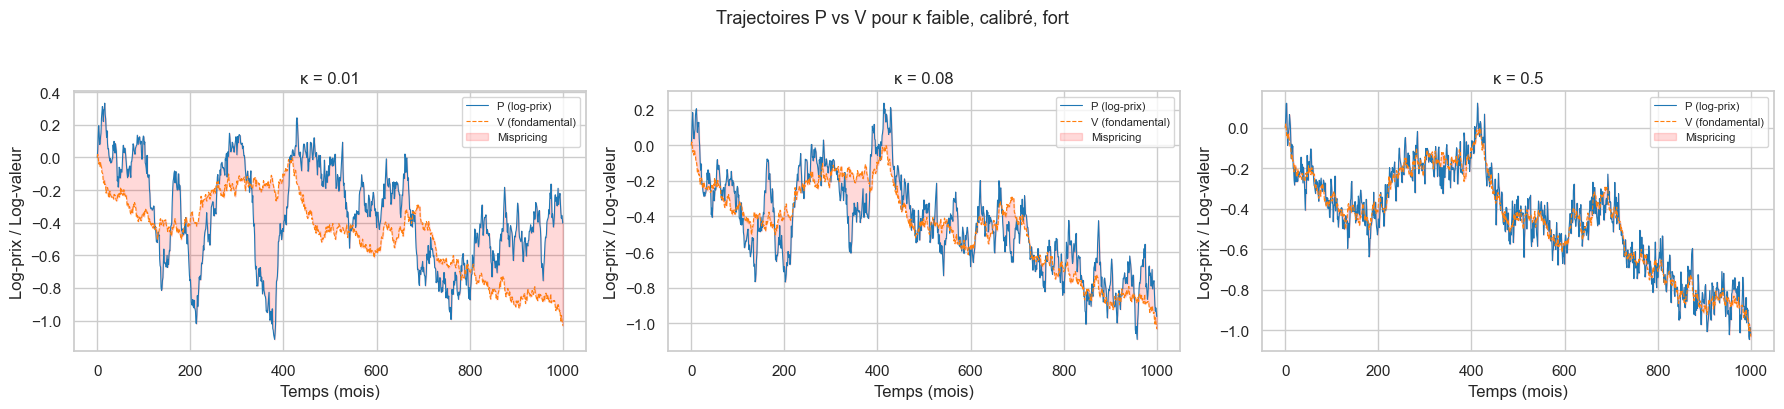

In [6]:
# On affiche κ faible, calibré, fort
kappa_showcase = [0.01, 0.08, 0.50]
showcase_records = [r for r in records if r['kappa'] in kappa_showcase]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)

for ax, rec in zip(axes, showcase_records):
    t = rec['_t']
    ax.plot(t, rec['_P'], label='P (log-prix)', linewidth=0.8)
    ax.plot(t, rec['_V'], label='V (fondamental)', linewidth=0.8, linestyle='--')
    ax.fill_between(t, rec['_P'], rec['_V'], alpha=0.15, color='red', label='Mispricing')
    ax.set_xlabel('Temps (mois)')
    ax.set_ylabel('Log-prix / Log-valeur')
    ax.set_title(f'κ = {rec["kappa"]}')
    ax.legend(fontsize=8)

fig.suptitle('Trajectoires P vs V pour κ faible, calibré, fort', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Distribution du mispricing selon κ

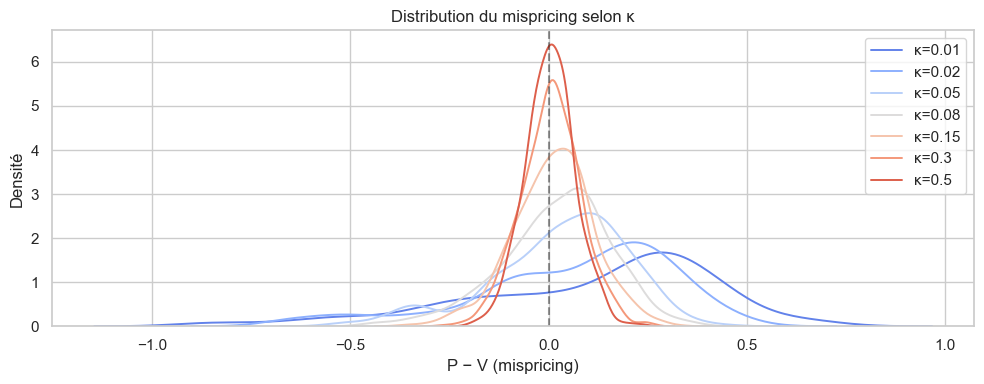

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = sns.color_palette('coolwarm', len(records))

for rec, color in zip(records, colors):
    mispricing = rec['_P'] - rec['_V']
    sns.kdeplot(mispricing, ax=ax, label=f"κ={rec['kappa']}", color=color, linewidth=1.4)

ax.axvline(0, color='black', linestyle='--', alpha=0.4)
ax.set_xlabel('P − V (mispricing)')
ax.set_ylabel('Densité')
ax.set_title('Distribution du mispricing selon κ')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Conclusions

### Résultats principaux

L'analyse de sensibilité sur κ ∈ {0.01, 0.02, 0.05, 0.08, 0.15, 0.30, 0.50} révèle un **arbitrage fondamental entre stabilité des bulles et volatilité des rendements** :

**Impact sur le mispricing (bulles) :**
- κ est le levier le plus puissant sur l'amplitude des bulles dans le modèle.
- Passer de κ = 0.01 à κ = 0.50 réduit Std(P−V) de 0.317 à 0.063 (−80 %) et Max|P−V| de 0.907 à 0.239 (−74 %).
- La relation est **monotone décroissante et convexe** : les gains marginaux sont très importants pour les petits κ, puis se tassent nettement au-delà de κ ≈ 0.15.
- Le baseline calibré (κ = 0.08) se situe dans la zone de forte sensibilité — une légère augmentation réduirait significativement les bulles.

**Impact sur la volatilité des rendements :**
- La volatilité des rendements évolue **en sens inverse** du mispricing : légèrement inférieure au baseline pour les petits κ (−2 % à κ=0.01), sensiblement supérieure pour les grands κ (+14 % à κ=0.50).
- Ce paradoxe apparent s'explique par la mécanique du rappel fondamental : un κ élevé génère des oscillations de correction fréquentes et énergiques vers V, qui se traduisent par plus de bruit à court terme dans les rendements même si les bulles sont contenues.

**Propriétés distributionnelles (skewness, kurtosis) :**
- Skewness et kurtosis excédentaire des rendements sont **quasi-insensibles à κ** (skewness ≈ 0.02–0.05 sur toute la plage). κ ne modifie pas la forme de la distribution des rendements, seulement l'amplitude des déviations prix/fondamentale.

### Bilan

κ est le paramètre qui gouverne le plus directement l'intensité du rappel fondamental. La valeur calibrée κ = 0.08 représente un équilibre entre la réduction des bulles et la préservation de la volatilité des rendements. Ces résultats servent de contexte pour le notebook 03 : dans une structure multi-fondamentalistes, le κ effectif est la somme pondérée des κ_i individuels, et les configurations avec κ_eff > 0.08 devraient donc réduire le mispricing — ce que confirment les simulations.